In [1]:
from update_data import *
from static import *
from test_and_visualize import *
from bao import *
from scipy.stats.mstats import winsorize

with open(PATH_DICTIONARY, "r") as a:
    DICTIONARY = json.load(a)

In [2]:
stock_data = get_cleaned_data(
    PATH_STOCK_DATA, PATH_TICKER, DICTIONARY
)

latest data date is 2024-11-08 00:00:00


In [3]:
stock_data = pd.concat(
    [stock_data] + get_indices_data(DICTIONARY), axis=0
)

In [4]:
# Compute market level return
market = (
    stock_data.groupby(["exchange", "time"])[
        [
            "return_weighted",
            "log_return_weighted",
        ]
    ]
    .sum()
    .reset_index()
)

## winsorize the outliner

In [5]:
market_winsored = pd.DataFrame()
for i in market["exchange"].unique():
    temp = market.loc[market["exchange"] == i]
    temp["return_weighted"] = winsorize(
        temp["return_weighted"], limits=[0.05, 0.05]
    )
    temp["log_return_weighted"] = winsorize(
        temp["log_return_weighted"], limits=[0.05, 0.05]
    )
    market_winsored = pd.concat([market_winsored, temp], axis=0)
    # Detect outliers using Z-score

# test stationary

In [7]:
for i in market["exchange"].unique():
    temp = market[market["exchange"] == i]["return_weighted"]
    returns = winsorize(temp, limits=[0.05, 0.05])
    print(i)
    adf_test(temp, 0.01)
    kpss_test(temp, 0.01)

DELISTED
ADF Test Results:
ADF Statistic: -5.6653246373946455
p-value: 9.179898357429256e-07
Critical Value (1%): -3.4325853286163874
Critical Value (5%): -2.8625276197775373
Critical Value (10%): -2.5672957374856296
Judgment: The series is likely stationary (Reject null hypothesis).


KPSS Test Results:
KPSS Statistic: 0.6065963107295933
p-value: 0.022036699024582426
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Value (1%): 0.739
Judgment: The series is likely stationary (Fail to reject null hypothesis).


HNX
ADF Test Results:
ADF Statistic: -6.35297783487879
p-value: 2.5835505252870792e-08
Critical Value (1%): -3.432583038656411
Critical Value (5%): -2.86252660839952
Critical Value (10%): -2.5672951990365
Judgment: The series is likely stationary (Reject null hypothesis).


KPSS Test Results:
KPSS Statistic: 2.4780646616912634
p-value: 0.01
Critical Value (10%): 0.347
Critical Value (5%): 0.463
Critical Value (2.5%): 0.574
Critical Valu

# Seasonarity

* with the cycle is 2 year: the trend is more observable

'DELISTED'

(2952,)

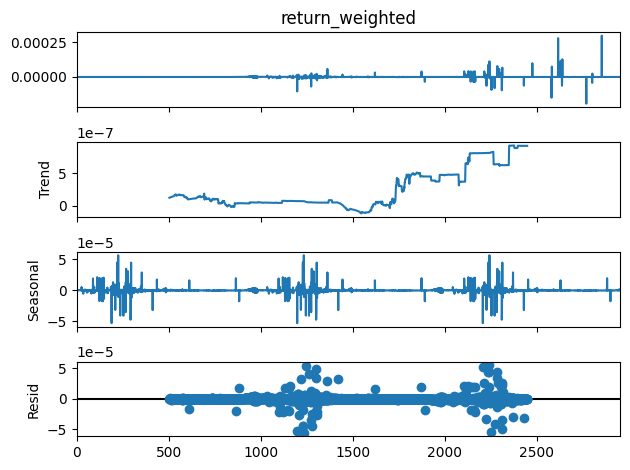

'HNX'

(2959,)

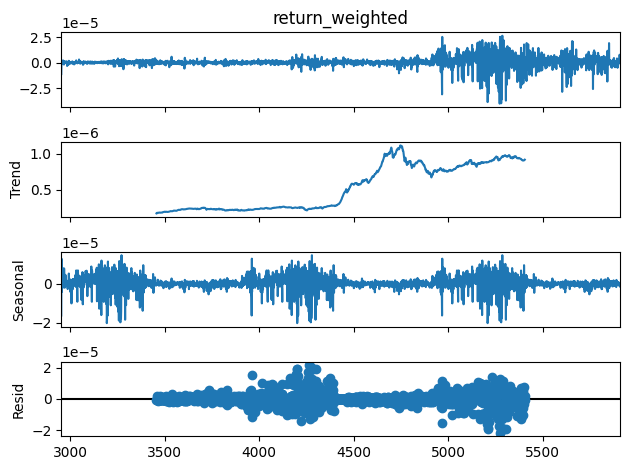

'HSX'

(2959,)

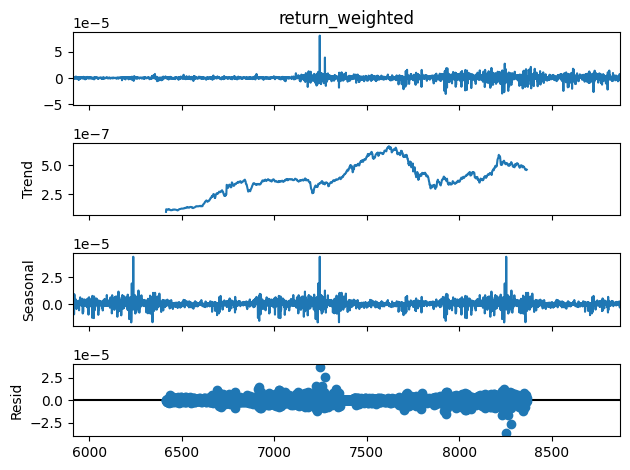

'UPCOM'

(2959,)

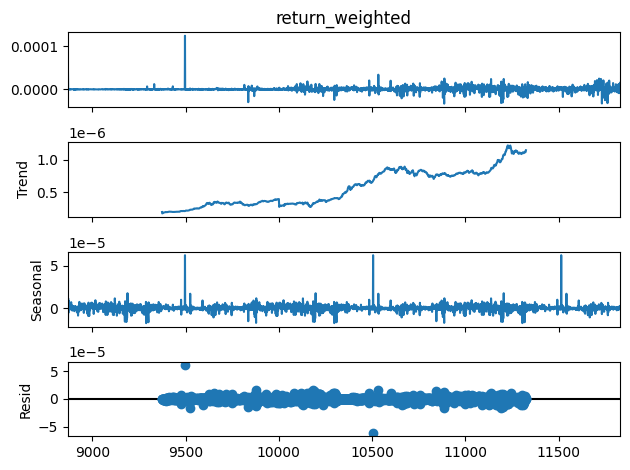

'vn30'

(1591,)

plot 1 year cycles


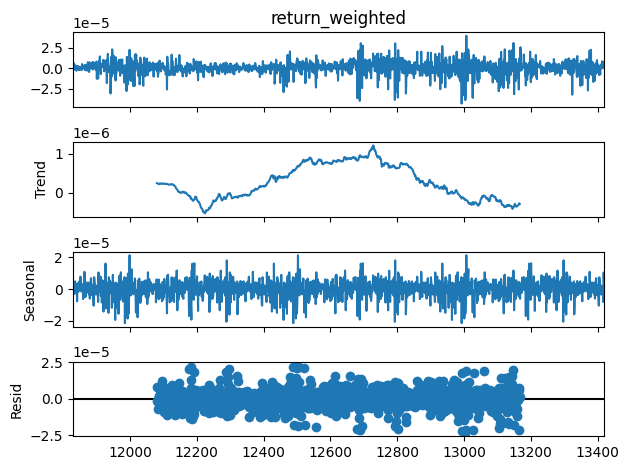

'vni'

(2745,)

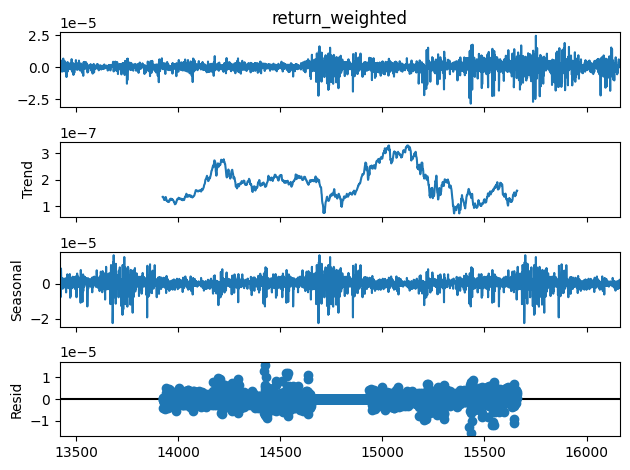

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 2
for i in market["exchange"].unique():
    try:
        temp = market[market["exchange"] == i]["return_weighted"]
        i
        temp.shape
        result = seasonal_decompose(
            temp, model="additive", period=period * 252 * 2
        )
        result.plot()
        plt.close()
    except ValueError:
        print("plot 1 year cycles")
        result = seasonal_decompose(
            temp, model="additive", period=period * 252
        )
        result.plot()
        plt.close()

* With 1 year cycle: the trend might not be so clear

'DELISTED'

(2952,)

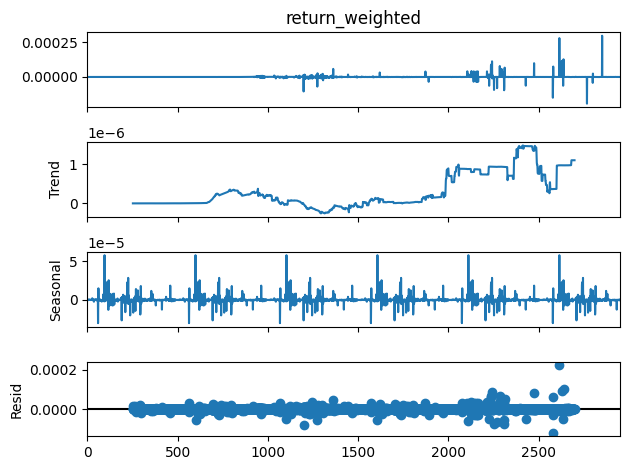

'HNX'

(2959,)

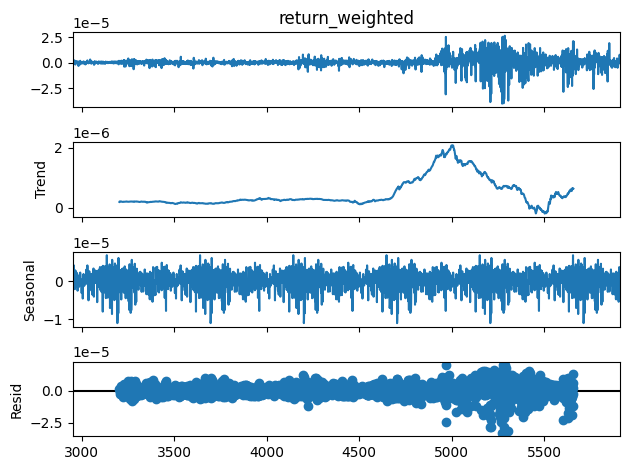

'HSX'

(2959,)

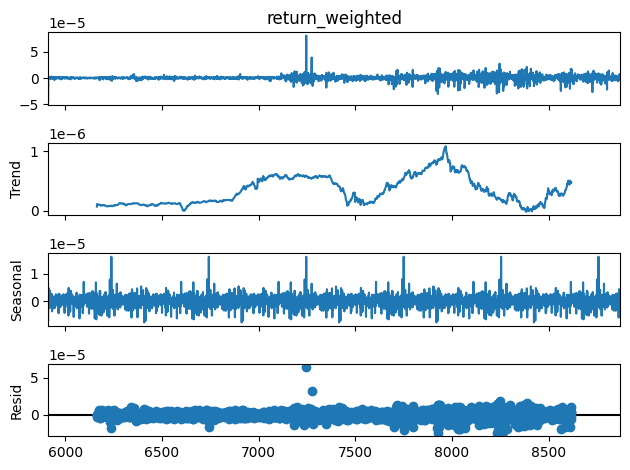

'UPCOM'

(2959,)

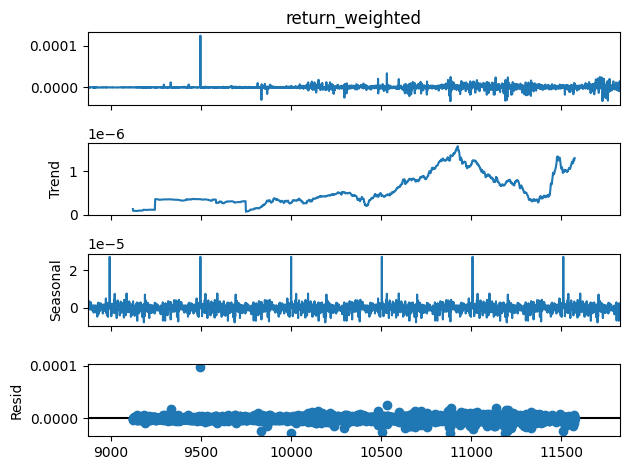

'vn30'

(1591,)

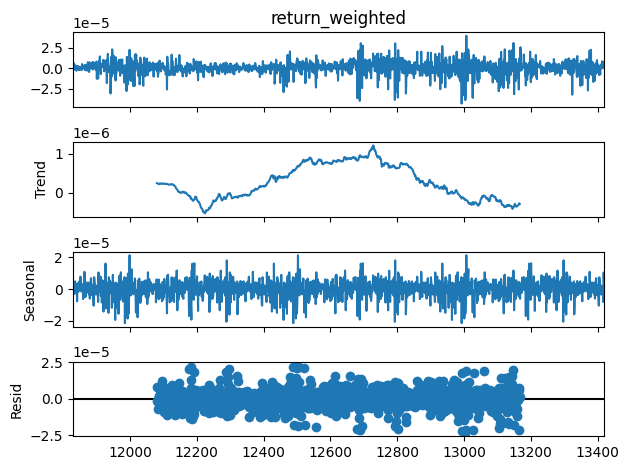

'vni'

(2745,)

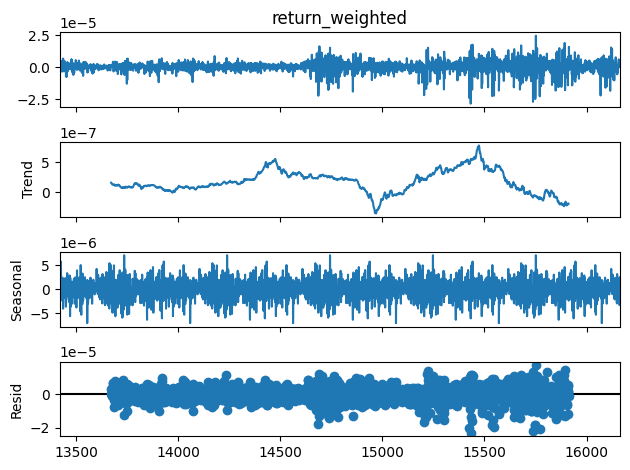

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 1
for i in market["exchange"].unique():
    try:
        temp = market[market["exchange"] == i]["return_weighted"]
        i
        temp.shape
        result = seasonal_decompose(
            temp, model="additive", period=period * 252 * 2
        )
        result.plot()
        plt.close()
    except ValueError:
        print("plot 1 year cycles")
        result = seasonal_decompose(
            temp, model="additive", period=period * 252
        )
        result.plot()
        plt.close()

HSX


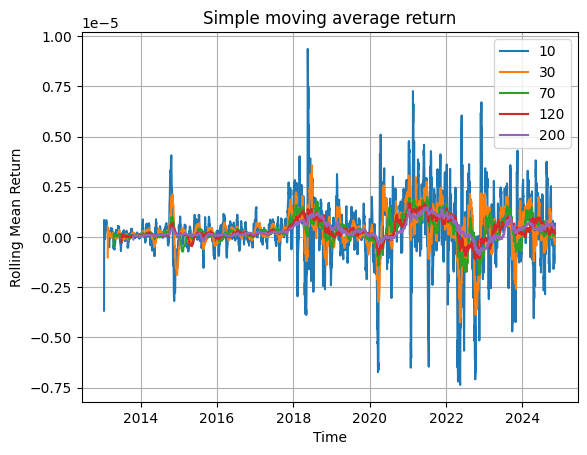

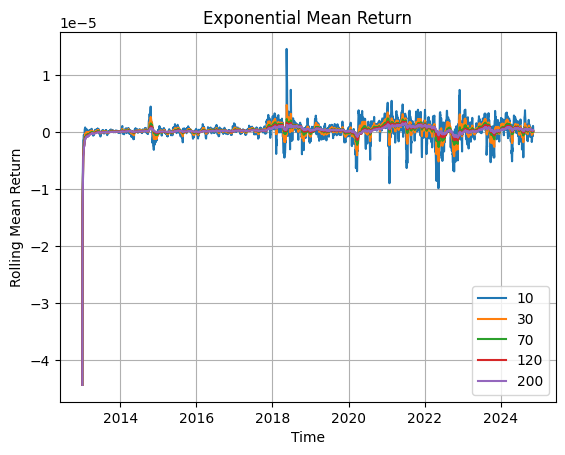

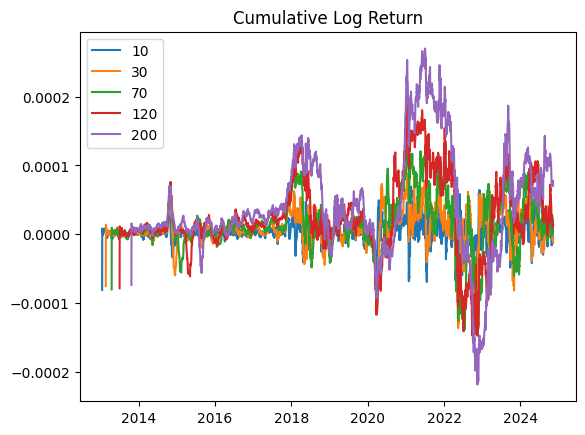

vn30


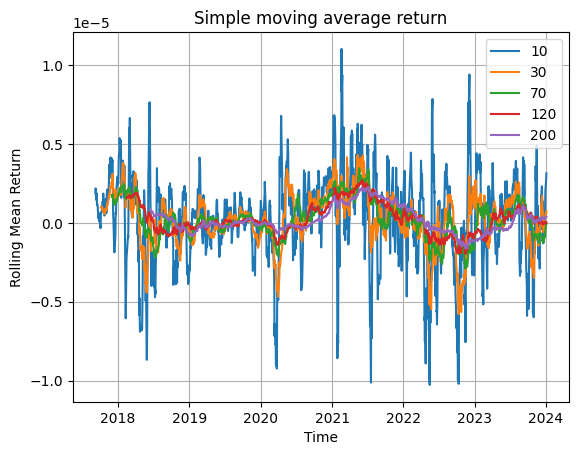

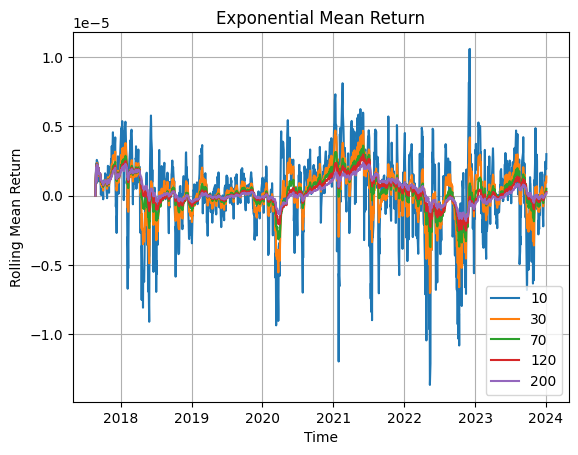

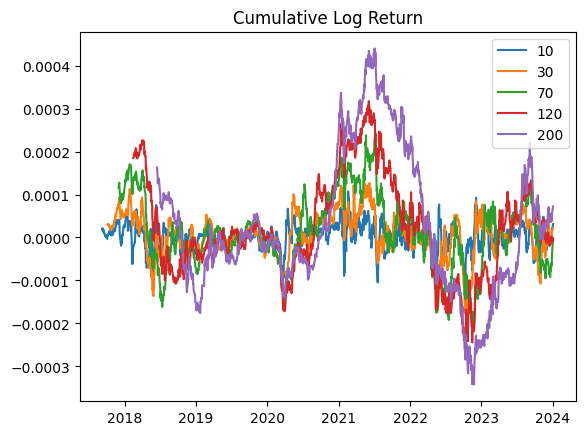

vni


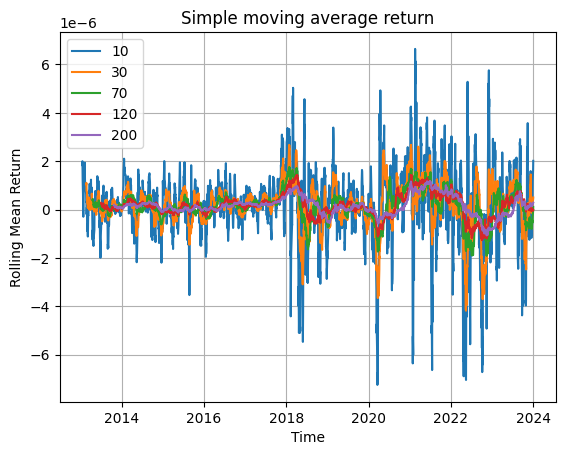

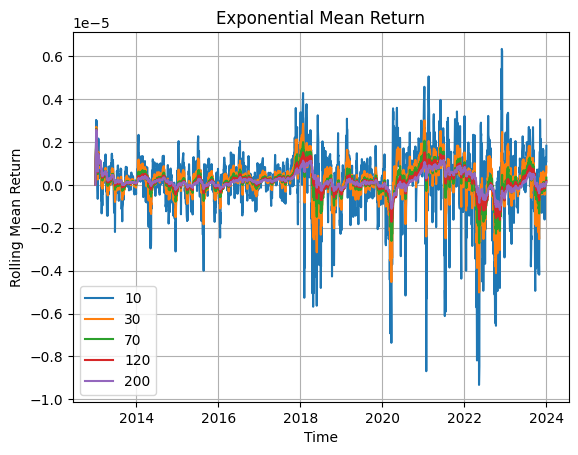

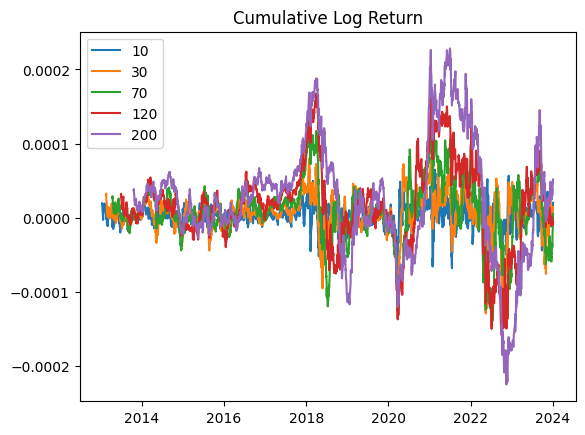

In [10]:
windows = [10, 30, 70, 120, 200]  # number of trading dates
for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        temp = market[market["exchange"] == i]
        print(i)
        simple_moving_average_visual(temp, "return_weighted", windows)
        exponential_moving_average_visual(
            temp, "return_weighted", windows
        )
        cumulative_visual(temp, "log_return_weighted", windows)

# Visualize with AR and ARIMA regression

'vni'

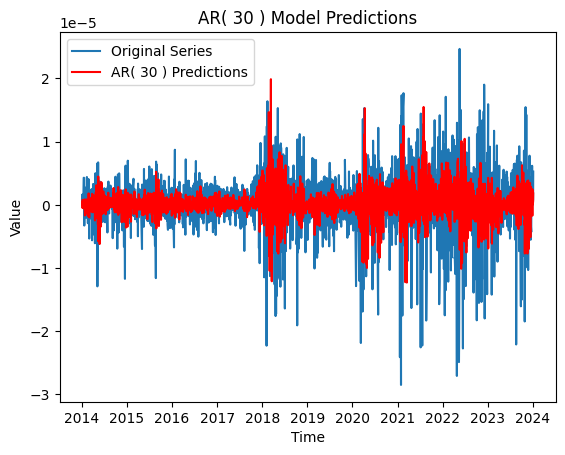

'HSX'

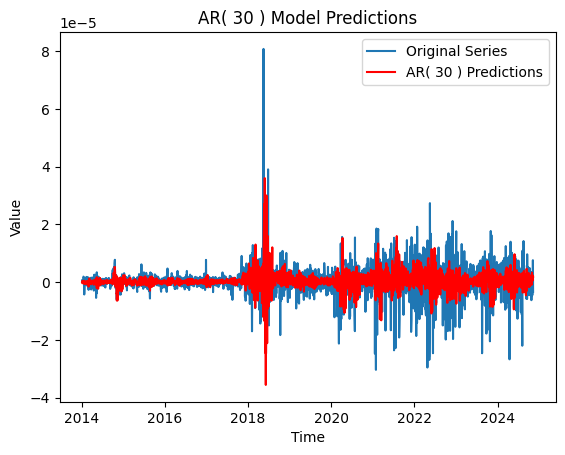

'vn30'

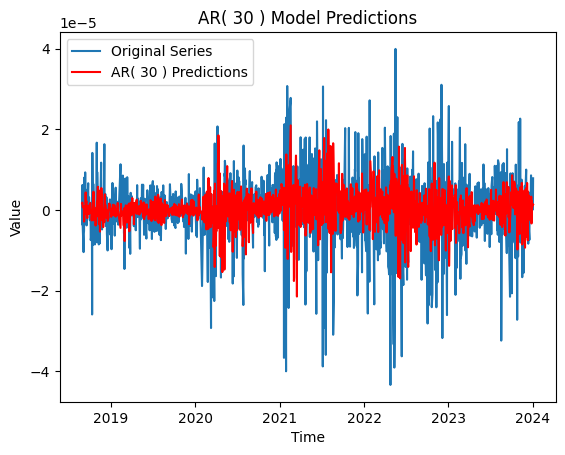

In [11]:
for i in ["vni", "HSX", "vn30"]:
    i
    df = real_time_auto_regression_visualize(
        market[market["exchange"] == i],
        "return_weighted",
        "time",
        252,
        30,
    )

'vni'

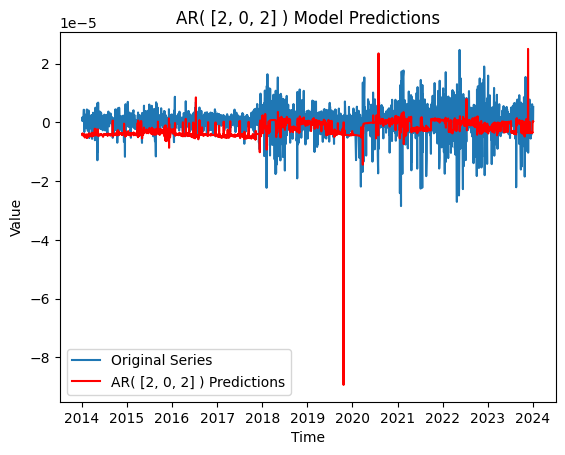

'HSX'

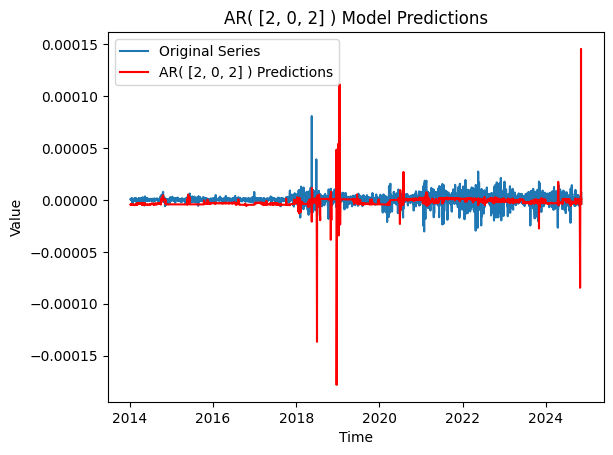

'vn30'

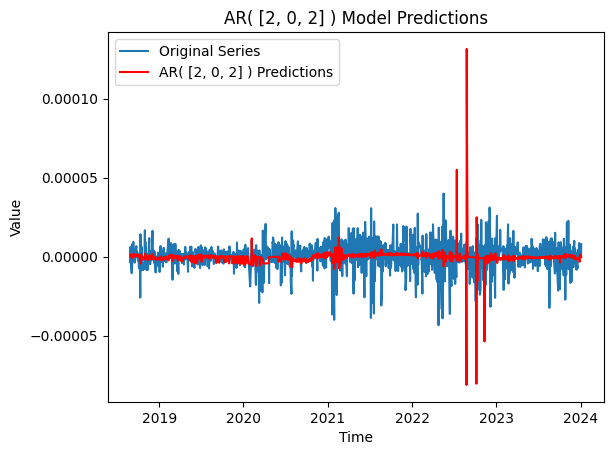

In [13]:
for i in ["vni", "HSX", "vn30"]:
    i
    df = real_time_arima_visualize(
        market[market["exchange"] == i],
        "return_weighted",
        "time",
        252,
        [2, 0, 2],
        # para=True,
    )